<a href="https://colab.research.google.com/github/sukaiakto/typos-correction/blob/main/typos_correction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Данные

In [1]:
!pip install openpyxl

In [2]:
import pandas as pd
import random
import re
import json
from html import unescape

INPUT_FILE = '/content/drive/MyDrive/All_OnlyData.xlsx'
OUTPUT_FILE = '/content/drive/MyDrive/spellcheck_dataset.jsonl'
MAX_PAIRS = 100000

def add_typos(text, min_errors=2, max_errors=8):
    if not text or len(text) < 5:
        return text

    chars = list(text)
    letter_indices = [i for i, c in enumerate(chars) if c.isalpha()]
    if len(letter_indices) < 3:
        return text

    num_errors = random.randint(min_errors, min(max_errors, len(letter_indices) // 3))
    error_positions = random.sample(letter_indices, num_errors)
    error_positions.sort(reverse=True)
    for i in error_positions:
        if i >= len(chars):
            continue

        typo_type = random.choice(['swap', 'delete', 'replace', 'insert', 'double'])
        if typo_type == 'swap' and i < len(chars) - 1 and chars[i+1].isalpha():
            chars[i], chars[i+1] = chars[i+1], chars[i]
        elif typo_type == 'delete':
            chars.pop(i)
        elif typo_type == 'replace':
            keyboard = 'йцукенгшщзхъфывапролджэячсмитьбю'
            char = chars[i]
            if char in keyboard:
                idx = keyboard.index(char)
                neighbors = []
                if idx > 0: neighbors.append(keyboard[idx-1])
                if idx < len(keyboard)-1: neighbors.append(keyboard[idx+1])
                if neighbors:
                    chars[i] = random.choice(neighbors)
        elif typo_type == 'insert':
            chars.insert(i + 1, random.choice('аоеинслт'))
        elif typo_type == 'double':
            chars.insert(i + 1, chars[i])

    return ''.join(chars)

def clean_headline(text):
    if not isinstance(text, str):
        return ""

    text = unescape(text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()

    return text

def is_valid_headline(text):
    if not text or len(text) < 10:
        return False

    if len(text) > 60:
        return False

    if text.startswith(('http', 'www')):
        return False

    if re.search(r'^[\d\s\.,:;]+$', text):
        return False

    if len(re.findall(r'[а-яa-z]', text)) < 3:
        return False

    if re.search(r'["\'«»„“”]', text):
        return False

    if re.search(r'[a-z]', text):
        return False

    return True

def main():
    df = pd.read_excel(INPUT_FILE)

    text_column = None
    for col in df.columns:
        if 'text' in col.lower() or 'name' in col.lower() or 'title' in col.lower() or 'headline' in col.lower():
            text_column = col
            break

    print(f"Всего строк: {len(df)}")

    clean_headlines = []
    for idx, row in df.iterrows():
        headline = clean_headline(row[text_column])
        if is_valid_headline(headline):
            clean_headlines.append(headline)

        if (idx + 1) % 50000 == 0:
            print(f"  Обработано строк: {idx + 1}")

    print(f"После фильтрации: {len(clean_headlines)} заголовков")
    print(f"\nГенерация пар")
    pairs = []
    pair_id = 1
    for clean_text in clean_headlines:
        num_variants = random.randint(2, 3)
        for _ in range(num_variants):
            noisy_text = add_typos(clean_text, min_errors=2, max_errors=8)
            if noisy_text == clean_text:
                continue
            pairs.append({"id": pair_id,
                          "source": noisy_text,
                          "target": clean_text})
            pair_id += 1
            if pair_id % 10000 == 0:
              print(f"  Сгенерировано: {pair_id}")

            if len(pairs) >= MAX_PAIRS:
                break
        if len(pairs) >= MAX_PAIRS:
            break

    print(f"Всего пар: {len(pairs)}")
    with open(OUTPUT_FILE, 'w', encoding='utf-8') as f:
        for pair in pairs:
            f.write(f'{pd.Series(pair).to_json()}\n')
    print(f"Сохранено в: {OUTPUT_FILE}")
    print("\nПримеры пар:")
    print()
    for i, pair in enumerate(pairs[:5]):
        print(f"\nПример {i+1}:")
        print(f"  Правильно:  {pair['target']}")
        print(f"  С ошибками: {pair['source']}")

if __name__ == '__main__':
    main()

Всего строк: 493490
  Обработано строк: 50000
  Обработано строк: 100000
  Обработано строк: 150000
  Обработано строк: 200000
  Обработано строк: 250000
  Обработано строк: 300000
  Обработано строк: 350000
  Обработано строк: 400000
  Обработано строк: 450000
После фильтрации: 209362 заголовков

Генерация пар
  Сгенерировано: 10000
  Сгенерировано: 20000
  Сгенерировано: 30000
  Сгенерировано: 40000
  Сгенерировано: 50000
  Сгенерировано: 60000
  Сгенерировано: 70000
  Сгенерировано: 80000
  Сгенерировано: 90000
  Сгенерировано: 100000
Всего пар: 100000
Сохранено в: /content/drive/MyDrive/spellcheck_dataset.jsonl

Примеры пар:


Пример 1:
  Правильно:  наса показало обратную сторону луны на фоне земли
  С ошибками: наса показлао обартную чторону ллуны на фоне земли

Пример 2:
  Правильно:  наса показало обратную сторону луны на фоне земли
  С ошибками: наса поеазало олбратную сторон лууны на фоне земмли

Пример 3:
  Правильно:  наса показало обратную сторону луны на фоне земли
  С ош

In [3]:
import json
import random

random.seed(42)
pairs = []
with open('/content/drive/MyDrive/spellcheck_dataset.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        pairs.append(json.loads(line))
random.shuffle(pairs)

n = len(pairs)
train_size = int(n * 0.8)
val_size = int(n * 0.1)
train = pairs[:train_size]
val = pairs[train_size:train_size + val_size]
test = pairs[train_size + val_size:]
for name, data in [('train', train), ('val', val), ('test', test)]:
    with open(f'/content/drive/MyDrive/{name}.jsonl', 'w', encoding='utf-8') as f:
        for pair in data:
            f.write(json.dumps(pair, ensure_ascii=False) + '\n')
    print(f"/content/drive/MyDrive/{name}.jsonl: {len(data)} пар")

print(f"Train:{len(train)} пар")
print(f"Val:{len(val)} пар")
print(f"Test:{len(test)} пар")

/content/drive/MyDrive/train.jsonl: 80000 пар
/content/drive/MyDrive/val.jsonl: 10000 пар
/content/drive/MyDrive/test.jsonl: 10000 пар
Train:80000 пар
Val:10000 пар
Test:10000 пар


In [4]:
import json
import random

random.seed(42)
pairs = []
c = 0
with open('/content/drive/MyDrive/spellcheck_dataset.jsonl', 'r', encoding='utf-8') as f:
    for line in f:
        pairs.append(json.loads(line))
        c += 1
        if c >= 50000:
          break
random.shuffle(pairs)

n = len(pairs)
train_size = int(n * 0.8)
val_size = int(n * 0.1)
train = pairs[:train_size]
val = pairs[train_size:train_size + val_size]
test = pairs[train_size + val_size:]

for name, data in [('train', train), ('val', val), ('test', test)]:
    with open(f'/content/drive/MyDrive/short_{name}.jsonl', 'w', encoding='utf-8') as f:
        for pair in data:
            f.write(json.dumps(pair, ensure_ascii=False) + '\n')
    print(f"/content/drive/MyDrive/short_{name}.jsonl: {len(data)} пар")

print(f"Train:{len(train)} пар (80%)")
print(f"Val:{len(val)} пар (10%)")
print(f"Test:{len(test)} пар (10%)")

/content/drive/MyDrive/short_train.jsonl: 40000 пар
/content/drive/MyDrive/short_val.jsonl: 5000 пар
/content/drive/MyDrive/short_test.jsonl: 5000 пар
Train:40000 пар (80%)
Val:5000 пар (10%)
Test:5000 пар (10%)


# Модель

In [5]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install pandas sacrebleu

Looking in indexes: https://download.pytorch.org/whl/cu118
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 8.7 MB/s eta 0:00:00


In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import random
import json
import time
import math
from collections import Counter
import sacrebleu
import matplotlib.pyplot as plt
import os

SEED = 45
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

class Config:
    DATA_PATH = '/content/drive/MyDrive/'
    EXP_TRAIN = 'short_train.jsonl'
    FINAL_TRAIN = 'train.jsonl'
    VAL = 'short_val.jsonl'
    TEST = 'short_test.jsonl'

    EMBEDDING_DIM = 256
    HIDDEN_DIM = 512
    NUM_LAYERS = 2
    DROPOUT = 0.3

    BIDIRECTIONAL = True

    BATCH_SIZE = 64
    LEARNING_RATE = 0.001
    NUM_EPOCHS_EXP = 10
    NUM_EPOCHS_FINAL = 15
    CLIP = 1.0

    MAX_LEN = 65
    VOCAB_SIZE = 3000

    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

config = Config()

print(f"Устройство: {config.DEVICE}")

Устройство: cuda


In [7]:
class Vocabulary:
    def __init__(self):
        self.itos = {0: "<PAD>", 1: "<SOS>", 2: "<EOS>", 3: "<UNK>"}
        self.stoi = {v: k for k, v in self.itos.items()}

    def __len__(self):
        return len(self.itos)

    def build_vocabulary(self, texts):
        char_freq = Counter()
        for text in texts:
            char_freq.update(list(text.lower()))
        idx = 4
        russian_letters = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя'
        for letter in russian_letters:
            if letter not in self.stoi:
                self.stoi[letter] = idx
                self.itos[idx] = letter
                idx += 1

        essential_chars = ' ,.!?:;-'
        for char in essential_chars:
            if char not in self.stoi:
                self.stoi[char] = idx
                self.itos[idx] = char
                idx += 1

    def numericalize(self, text):
        tokens = list(text.lower())
        return [self.stoi.get(token, self.stoi["<UNK>"]) for token in tokens]

    def textualize(self, indices):
        return ''.join([self.itos.get(idx, "") for idx in indices if idx not in [0, 1, 2, 3]])

input_vocab = Vocabulary()
output_vocab = Vocabulary()

In [8]:
import re
from html import unescape
from torch.utils.data import Dataset, DataLoader

def clean_text(text):
    text = re.sub(r'[^а-яё\s,.!?:;-]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

class SpellCheckDataset(Dataset):
    def __init__(self, jsonl_path, input_vocab, output_vocab, max_len=60):
        self.data = []
        self.input_vocab = input_vocab
        self.output_vocab = output_vocab
        self.max_len = max_len

        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line in f:
                pair = json.loads(line)
                source = clean_text(pair['source'])
                target = clean_text(pair['target'])
                if len(source) > 5 and len(target) > 5:
                    self.data.append({'source': source, 'target': target})

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        pair = self.data[idx]
        source = pair['source']
        target = pair['target']
        source_indices = self.input_vocab.numericalize(source)
        target_indices = self.output_vocab.numericalize(target)
        if len(source_indices) > self.max_len:
            source_indices = source_indices[:self.max_len]
        if len(target_indices) > self.max_len:
            target_indices = target_indices[:self.max_len]

        source_indices = [self.input_vocab.stoi["<SOS>"]] + source_indices + [self.input_vocab.stoi["<EOS>"]]
        target_indices = [self.output_vocab.stoi["<SOS>"]] + target_indices + [self.output_vocab.stoi["<EOS>"]]
        source_tensor = torch.zeros(self.max_len + 2, dtype=torch.long)
        target_tensor = torch.zeros(self.max_len + 2, dtype=torch.long)
        source_tensor[:len(source_indices)] = torch.tensor(source_indices)
        target_tensor[:len(target_indices)] = torch.tensor(target_indices)
        return source_tensor, target_tensor

def load_data(train_path, val_path, batch_size=64):
    global input_vocab, output_vocab

    texts = []
    for path in [train_path, val_path]:
        with open(path, 'r', encoding='utf-8') as f:
            for line in f:
                pair = json.loads(line)
                texts.append(pair['source'])
                texts.append(pair['target'])

    input_vocab.build_vocabulary(texts)
    output_vocab.build_vocabulary(texts)
    train_dataset = SpellCheckDataset(train_path, input_vocab, output_vocab, config.MAX_LEN)
    val_dataset = SpellCheckDataset(val_path, input_vocab, output_vocab, config.MAX_LEN)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader

In [9]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim,
                 num_layers, dropout, bidirectional=True):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.num_directions = 2 if bidirectional else 1
        self.embedding = nn.Embedding(vocab_size,
                                      embedding_dim,
                                      padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim,
                            hidden_dim,
                            num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0,
                            batch_first=True,
                            bidirectional=bidirectional)
        self.fc_hidden = nn.Linear(hidden_dim * self.num_directions, hidden_dim)
        self.fc_cell = nn.Linear(hidden_dim * self.num_directions, hidden_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        embedded = self.dropout(self.embedding(src))
        outputs, (hidden, cell) = self.lstm(embedded)
        if self.bidirectional:
            hidden_cat = torch.cat((hidden[-2], hidden[-1]), dim=1)
            cell_cat = torch.cat((cell[-2], cell[-1]), dim=1)
            hidden = torch.tanh(self.fc_hidden(hidden_cat))
            cell = torch.tanh(self.fc_cell(cell_cat))
        else:
            hidden = hidden[-1]
            cell = cell[-1]
        return outputs, hidden, cell


class Decoder(nn.Module):
    def __init__(self, output_dim, embedding_dim, hidden_dim,
                 num_layers, dropout, encoder_directions=2):
        super().__init__()

        self.hidden_dim = hidden_dim
        self.embedding_dim = embedding_dim
        self.num_layers = num_layers
        self.encoder_output_dim = hidden_dim * encoder_directions
        self.attn = nn.Linear(hidden_dim + self.encoder_output_dim,
                              hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)
        self.embedding = nn.Embedding(output_dim,
                                      embedding_dim,
                                      padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim + self.encoder_output_dim,
                            hidden_dim,
                            num_layers=num_layers,
                            dropout=dropout if num_layers > 1 else 0,
                            batch_first=True)
        fc_in = hidden_dim + self.encoder_output_dim + embedding_dim
        self.fc = nn.Linear(fc_in, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input, hidden, cell, encoder_outputs, mask):
        input = input.unsqueeze(1)
        batch_size = input.shape[0]
        src_len = encoder_outputs.shape[1]
        hidden_rep = hidden.unsqueeze(1).repeat(1, src_len, 1)
        energy = torch.tanh(self.attn(torch.cat((hidden_rep, encoder_outputs), dim=2)))
        attention = self.v(energy).squeeze(2)
        attention = attention.masked_fill(mask == 0, -1e10)
        attention = torch.softmax(attention, dim=1)
        attended = torch.bmm(attention.unsqueeze(1),
                             encoder_outputs)
        embedded = self.dropout(self.embedding(input))
        lstm_in = torch.cat((embedded, attended), dim=2)
        hidden_lstm = hidden.unsqueeze(0).repeat(self.num_layers, 1, 1)
        cell_lstm = cell.unsqueeze(0).repeat(self.num_layers, 1, 1)
        output, (hidden, cell) = self.lstm(lstm_in, (hidden_lstm, cell_lstm))
        fc_input = torch.cat((output.squeeze(1), attended.squeeze(1), embedded.squeeze(1)), dim=1)
        output = self.fc(fc_input)
        return output, hidden[-1], cell[-1], attention


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def create_mask(self, src):
        return (src != 0).to(self.device)

    def forward(self, src, trg, teacher_forcing_ratio=0.5):
        batch_size = src.shape[0]
        trg_len = trg.shape[1]
        trg_vocab_size = self.decoder.fc.out_features
        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src)
        mask = self.create_mask(src)
        input = trg[:, 0]
        for t in range(1, trg_len):
            output, hidden, cell, _ = self.decoder(input,
                                                   hidden,
                                                   cell,
                                                   encoder_outputs,
                                                   mask)
            outputs[:, t] = output
            top1 = output.argmax(1)
            teacher_force = random.random() < teacher_forcing_ratio
            input = trg[:, t] if teacher_force else top1
        return outputs


In [10]:
def initialize_model(input_vocab_size, output_vocab_size, config):
    print(f"HIDDEN_DIM: {config.HIDDEN_DIM}")
    print(f"embedding_dim: {config.EMBEDDING_DIM}")
    print(f"num_layers: {config.NUM_LAYERS}")
    print(f"bidirectional: {config.BIDIRECTIONAL}")

    encoder_directions = 2 if config.BIDIRECTIONAL else 1

    print(f"encoder_directions: {encoder_directions}")

    encoder = Encoder(vocab_size=input_vocab_size,
                      embedding_dim=config.EMBEDDING_DIM,
                      hidden_dim=config.HIDDEN_DIM,
                      num_layers=config.NUM_LAYERS,
                      dropout=config.DROPOUT,
                      bidirectional=config.BIDIRECTIONAL)

    decoder = Decoder(output_dim=output_vocab_size,
                      embedding_dim=config.EMBEDDING_DIM,
                      hidden_dim=config.HIDDEN_DIM,
                      num_layers=config.NUM_LAYERS,
                      dropout=config.DROPOUT,
                      encoder_directions=encoder_directions)

    model = Seq2Seq(encoder, decoder, config.DEVICE).to(config.DEVICE)

    def init_weights(m):
        for name, param in m.named_parameters():
            if 'weight' in name and param.dim() > 1:
                nn.init.xavier_uniform_(param)

    model.apply(init_weights)
    print(
        f" Параметры модели: "
        f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}"
    )

    return model

In [11]:
def train_epoch(model, dataloader, optimizer, criterion, clip, teacher_forcing_ratio):
    model.train()
    epoch_loss = 0

    for batch_idx, (src, trg) in enumerate(dataloader):
        src = src.to(config.DEVICE)
        trg = trg.to(config.DEVICE)
        optimizer.zero_grad()
        output = model(src, trg, teacher_forcing_ratio)
        output = output[:, 1:].reshape(-1, output.shape[-1])
        trg = trg[:, 1:].reshape(-1)
        loss = criterion(output, trg)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()
        epoch_loss += loss.item()
        if batch_idx % 100 == 0:
            print(f"  Batch {batch_idx}/{len(dataloader)}, Loss: {loss.item():.4f}")
    return epoch_loss / len(dataloader)

def evaluate(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0
    with torch.no_grad():
        for src, trg in dataloader:
            src = src.to(config.DEVICE)
            trg = trg.to(config.DEVICE)
            output = model(src, trg, teacher_forcing_ratio=0)
            output = output[:, 1:].reshape(-1, output.shape[-1])
            trg = trg[:, 1:].reshape(-1)
            loss = criterion(output, trg)
            epoch_loss += loss.item()
    return epoch_loss / len(dataloader)

def train_model(model, train_loader, val_loader, num_epochs, model_name="model"):
    optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
    criterion = nn.CrossEntropyLoss(ignore_index=0)
    best_val_loss = float('inf')
    history = {'train_loss': [], 'val_loss': []}
    print(f"\nНачало обучения ({num_epochs} эпох)")
    for epoch in range(num_epochs):
        start_time = time.time()
        tf_ratio = max(0.5 - epoch * 0.05, 0.1)
        train_loss = train_epoch(model, train_loader, optimizer, criterion, config.CLIP, tf_ratio)
        val_loss = evaluate(model, val_loader, criterion)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        epoch_time = time.time() - start_time
        print(f"\nEpoch {epoch+1}/{num_epochs} | Train Loss: {train_loss:.4f} |",
              f"Val Loss: {val_loss:.4f} | Time: {epoch_time:.1f}s")
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save({'epoch': epoch,
                        'model_state_dict': model.state_dict(),
                        'optimizer_state_dict': optimizer.state_dict(),
                        'val_loss': val_loss,}, f'/content/{model_name}_best.pth')
            print(f"  Сохранена лучшая модель (val_loss: {val_loss:.4f})")
    plt.figure(figsize=(10, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training History - {model_name}')
    plt.legend()
    plt.grid(True)
    plt.show()
    return history

In [12]:
def translate_sentence(model, sentence, input_vocab, output_vocab, max_len=60):
    model.eval()

    with torch.no_grad():
        tokens = list(sentence.lower())
        indices = [input_vocab.stoi.get(t, input_vocab.stoi["<UNK>"]) for t in tokens]
        if len(indices) > max_len:
            indices = indices[:max_len]

        indices = [input_vocab.stoi["<SOS>"]] + indices + [input_vocab.stoi["<EOS>"]]
        src = torch.zeros(max_len + 2, dtype=torch.long).to(config.DEVICE).unsqueeze(0)
        src[0, :len(indices)] = torch.tensor(indices)
        mask = (src != 0).to(config.DEVICE)
        encoder_outputs, hidden, cell = model.encoder(src)
        input_token = torch.tensor([output_vocab.stoi["<SOS>"]]).to(config.DEVICE)
        translated_indices = []
        for _ in range(max_len):
            output, hidden, cell, _ = model.decoder(input_token, hidden, cell, encoder_outputs, mask)
            top1 = output.argmax(1)
            if top1.item() == output_vocab.stoi["<EOS>"]:
                break

            translated_indices.append(top1.item())
            input_token = top1
        translated_chars = [output_vocab.itos[idx] for idx in translated_indices]
        return ''.join(translated_chars)

def calculate_wer(prediction, reference):
    pred_words = prediction.split()
    ref_words = reference.split()
    if len(ref_words) == 0:
        return 100.0 if len(pred_words) > 0 else 0.0
    m, n = len(pred_words), len(ref_words)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i  # Удаления
    for j in range(n + 1):
        dp[0][j] = j  # Вставки
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if pred_words[i-1] == ref_words[j-1]:
                dp[i][j] = dp[i-1][j-1]  # Совпадение
            else:
                dp[i][j] = 1 + min(dp[i-1][j], # Удаление
                                   dp[i][j-1], # Вставка
                                   dp[i-1][j-1]) # Замена
    edit_distance = dp[m][n]
    wer = (edit_distance / len(ref_words)) * 100
    return wer

def calculate_cer(prediction, reference):
    if len(reference) == 0:
        return 100.0 if len(prediction) > 0 else 0.0
    m, n = len(prediction), len(reference)
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            if prediction[i-1] == reference[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j],      # удаление
                                   dp[i][j-1],      # вставка
                                   dp[i-1][j-1])    # замена

    edit_distance = dp[m][n]
    cer = (edit_distance / len(reference)) * 100
    return cer

def evaluate_on_test(model, test_path, input_vocab, output_vocab, show_examples=20):
    model.eval()
    predictions = []
    references = []
    print(f"\nПримеры исправлений (первые {show_examples}):")
    total_samples = 0
    with open(test_path, 'r', encoding='utf-8') as f:
        for line in f:
            pair = json.loads(line)
            source = pair['source'].lower()
            target = pair['target'].lower()
            prediction = translate_sentence(model,
                                            source,
                                            input_vocab,
                                            output_vocab,
                                            max_len=config.MAX_LEN)

            predictions.append(prediction)
            references.append([target])
            if total_samples < show_examples:
                print(f"\n{total_samples + 1}. С ошибкой:   {source}")
                print(f"   Цель:       {target}")
                print(f"   Предсказано:{prediction}")
                print(f"   {'Верно' if prediction == target else 'Ошибка'}")
            total_samples += 1

    print(f"Проверено примеров: {total_samples}")
    cer_scores = [calculate_cer(pred, ref[0]) for pred, ref in zip(predictions, references)]
    cer_avg = np.mean(cer_scores)
    wer_scores = [calculate_wer(pred, ref[0]) for pred, ref in zip(predictions, references)]
    wer_avg = np.mean(wer_scores)
    exact_matches = sum(pred == ref[0] for pred, ref in zip(predictions, references))
    accuracy = exact_matches / len(predictions) * 100
    return cer_avg, wer_avg, accuracy

50 тыс. данных
HIDDEN_DIM: 512
embedding_dim: 256
num_layers: 2
bidirectional: True
encoder_directions: 2
 Параметры модели: 17,169,709

Начало обучения (10 эпох)
  Batch 0/625, Loss: 3.8122
  Batch 100/625, Loss: 2.7374
  Batch 200/625, Loss: 2.5117
  Batch 300/625, Loss: 1.5286
  Batch 400/625, Loss: 0.9192
  Batch 500/625, Loss: 0.9325
  Batch 600/625, Loss: 0.7189

Epoch 1/10 | Train Loss: 1.7178 | Val Loss: 2.3371 | Time: 429.5s
  Сохранена лучшая модель (val_loss: 2.3371)
  Batch 0/625, Loss: 0.8367
  Batch 100/625, Loss: 1.2489
  Batch 200/625, Loss: 0.5495
  Batch 300/625, Loss: 0.5383
  Batch 400/625, Loss: 0.7056
  Batch 500/625, Loss: 0.5014
  Batch 600/625, Loss: 0.4954

Epoch 2/10 | Train Loss: 0.6819 | Val Loss: 2.0840 | Time: 434.3s
  Сохранена лучшая модель (val_loss: 2.0840)
  Batch 0/625, Loss: 0.8391
  Batch 100/625, Loss: 0.5292
  Batch 200/625, Loss: 0.4513
  Batch 300/625, Loss: 0.4638
  Batch 400/625, Loss: 0.6211
  Batch 500/625, Loss: 0.4420
  Batch 600/625, Lo

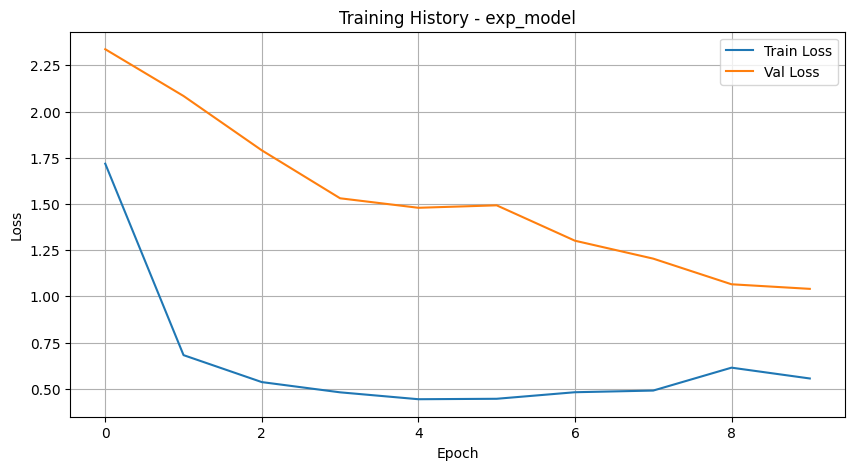


Примеры исправлений (первые 20):

1. С ошибкой:   умер диссиднт борис упстыннцев
   Цель:       умер диссидент борис пустынцев
   Предсказано:умер диссидет борис упастнецев
   Ошибка

2. С ошибкой:   в маериканском университете произошел инцидент со стрельбой
   Цель:       в американском университете произошел инцидент со стрельбой
   Предсказано:в мариканском университете произошел инцидент со стрельбой
   Ошибка

3. С ошибкой:   задержан уучастники наппдления на юветлирный садон  москв
   Цель:       задержаны участники нападения на ювелирный салон в москве
   Предсказано:задержан участники нападления на юветлирный садон м соскв
   Ошибка

4. С ошибкой:   бывший генсек нтаои арскритиковал обму за нрешиетьлность
   Цель:       бывший генсек нато раскритиковал обаму за нерешительность
   Предсказано:бывший генсек натии раскритиковал обму за решеттьнность
   Ошибка

5. С ошибкой:   минооброны украины отбъяснило присутстви танков в авдеевке
   Цель:       минобороны украины объяснило п

In [13]:
print("50 тыс. данных")

if not os.path.exists(config.DATA_PATH + config.EXP_TRAIN):
    print(f"Файл не найден")
else:
    train_loader, val_loader = load_data(config.DATA_PATH + config.EXP_TRAIN,
                                         config.DATA_PATH + config.VAL,
                                         batch_size=config.BATCH_SIZE)
    model = initialize_model(len(input_vocab), len(output_vocab), config)
    history_exp = train_model(model,
                              train_loader,
                              val_loader,
                              num_epochs=config.NUM_EPOCHS_EXP,
                              model_name="exp_model")
    if os.path.exists(config.DATA_PATH + config.TEST):
        cer, wer, acc = evaluate_on_test(model,
                                         config.DATA_PATH + config.TEST,
                                         input_vocab,
                                         output_vocab)
        print(f"\nИТОГО")
        print(f"CER: {cer:.2f}%")
        print(f"WER: {wer:.2f}%")
        print(f"Accuracy: {acc:.2f}%")
    else:
        print("Тестовый файл не найден")

In [14]:
input_vocab = Vocabulary()
output_vocab = Vocabulary()
print(" Словари сброшены")
print(f"input_vocab размер: {len(input_vocab)}")
print(f"output_vocab размер: {len(output_vocab)}")

print("100 тыс.данных")

if os.path.exists(config.DATA_PATH + config.FINAL_TRAIN):
    train_loader_final, val_loader_final = load_data(config.DATA_PATH + config.FINAL_TRAIN,
                                                     config.DATA_PATH + config.VAL,
                                                     batch_size=config.BATCH_SIZE)
    model_final = initialize_model(len(input_vocab), len(output_vocab), config)
    history_final = train_model(model_final,
                                train_loader_final,
                                val_loader_final,
                                num_epochs=config.NUM_EPOCHS_FINAL,
                                model_name="final_model")
    print("\n Загрузка лучшей модели...")
    checkpoint = torch.load('/content/final_model_best.pth', map_location=config.DEVICE)
    model_final.load_state_dict(checkpoint['model_state_dict'])
    print(f" Загружена модель с эпохи {checkpoint['epoch']+1} (Val Loss: {checkpoint['val_loss']:.4f})")
    print("\n ФИНАЛЬНАЯ ОЦЕНКА:")
    cer_final, wer_final, acc_final = evaluate_on_test(model_final,
                                                       config.DATA_PATH + config.TEST,
                                                       input_vocab,
                                                       output_vocab,
                                                       show_examples=30)

    print(f"\n ИТОГОВЫЕ РЕЗУЛЬТАТЫ:")
    print(f"   CER: {cer_final:.2f}%")
    print(f"   WER: {wer_final:.2f}%")
    print(f"   Accuracy: {acc_final:.2f}%")

    # Сохранение
    !cp /content/final_model_best.pth /content/drive/MyDrive/
    print("Модель сохранена")
else:
    print(f"Файл не найден")

 Словари сброшены
input_vocab размер: 4
output_vocab размер: 4
100 тыс.данных
HIDDEN_DIM: 512
embedding_dim: 256
num_layers: 2
bidirectional: True
encoder_directions: 2
 Параметры модели: 17,169,709

Начало обучения (15 эпох)
  Batch 0/1250, Loss: 3.8074
  Batch 100/1250, Loss: 2.7508
  Batch 200/1250, Loss: 2.1834
  Batch 300/1250, Loss: 1.3332
  Batch 400/1250, Loss: 1.2301
  Batch 500/1250, Loss: 1.0856


KeyboardInterrupt: 

In [19]:
print("\n Загрузка лучшей модели...")
checkpoint = torch.load('/content/drive/MyDrive/final_model_best.pth', map_location=config.DEVICE)
model_final.load_state_dict(checkpoint['model_state_dict'])
print(f" Загружена модель с эпохи {checkpoint['epoch']+1} (Val Loss: {checkpoint['val_loss']:.4f})")
print("\n ФИНАЛЬНАЯ ОЦЕНКА:")
cer_final, wer_final, acc_final = evaluate_on_test(model_final,
                                                   config.DATA_PATH + config.TEST,
                                                   input_vocab,
                                                   output_vocab,
                                                   show_examples=30)

print(f"\n ИТОГОВЫЕ РЕЗУЛЬТАТЫ:")
print(f"   CER: {cer_final:.2f}%")
print(f"   WER: {wer_final:.2f}%")
print(f"   Accuracy: {acc_final:.2f}%")


 Загрузка лучшей модели...
 Загружена модель с эпохи 15 (Val Loss: 0.4805)

 ФИНАЛЬНАЯ ОЦЕНКА:

Примеры исправлений (первые 30):

1. С ошибкой:   умер диссиднт борис упстыннцев
   Цель:       умер диссидент борис пустынцев
   Предсказано:умер диссидент борис упссынцевв
   Ошибка

2. С ошибкой:   в маериканском университете произошел инцидент со стрельбой
   Цель:       в американском университете произошел инцидент со стрельбой
   Предсказано:в американском университете произошел инцидент со стрельбой
   Верно

3. С ошибкой:   задержан уучастники наппдления на юветлирный садон  москв
   Цель:       задержаны участники нападения на ювелирный салон в москве
   Предсказано:задержан участники нападления на ювеллирный садон в москв
   Ошибка

4. С ошибкой:   бывший генсек нтаои арскритиковал обму за нрешиетьлность
   Цель:       бывший генсек нато раскритиковал обаму за нерешительность
   Предсказано:бывший генсек натали раскритиковал обму за нерешитьность
   Ошибка

5. С ошибкой:   минооб

NameError: name 'history_final' is not defined

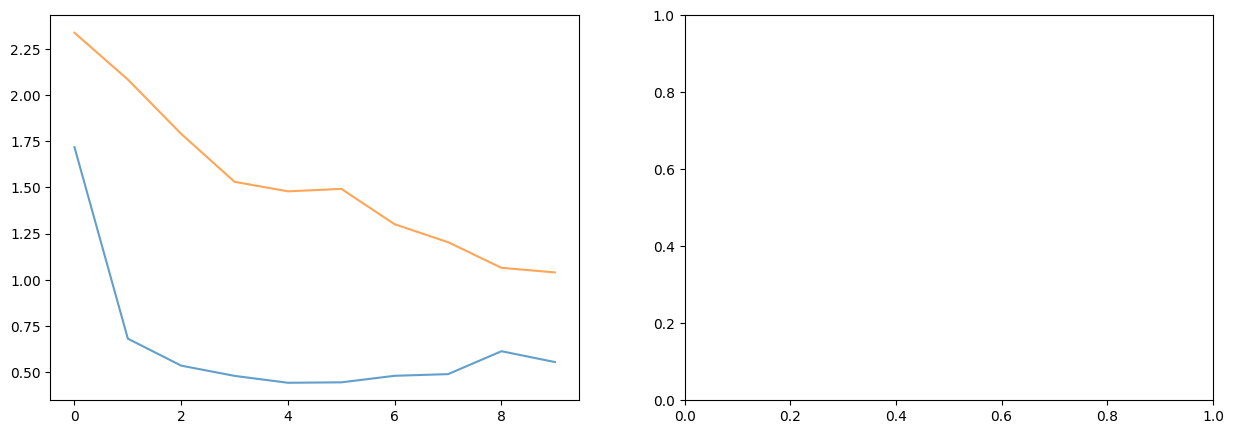

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(history_exp['train_loss'], label='Exp Train', alpha=0.7)
axes[0].plot(history_exp['val_loss'], label='Exp Val', alpha=0.7)
axes[0].plot(range(len(history_final['train_loss'])), history_final['train_loss'],
             label='Final Train', linewidth=2)
axes[0].plot(range(len(history_final['val_loss'])), history_final['val_loss'],
             label='Final Val', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training Loss Comparison')
axes[0].legend()
axes[0].grid(True)

sample_texts = [
    "привет ккак длеа",
    "сегодня хорошя погоды",
    'угроза ввзрыва на савелоаском возкале окатзалась ложной',
    'скакова лоншадь съела жоппинг на поастбищще',
    'нвса показало обоатную сторону лауны на фоне земди',
    'cуд арсстовал петербуржцаы, облившего кислоотой свою бфвшую'
]

model_final.eval()
corrections = []
for text in sample_texts:
    corrected = translate_sentence(model_final, text, input_vocab, output_vocab)
    corrections.append(corrected)

axes[1].axis('off')

table_data = [['Исходный текст', 'Исправлено']] + list(zip(sample_texts, corrections))
table = axes[1].table(cellText=table_data, loc='center', cellLoc='center')
table.auto_set_font_size(True)
#table.set_fontsize(10)
table.scale(2.2, 2.5)

plt.tight_layout()
plt.show()

In [ ]:
print("🔍 ДИАГНОСТИКА МОДЕЛИ")
print("=" * 60)

# 1. Проверка словаря
print("\n1. Словарь output_vocab:")
print(f"   Размер: {len(output_vocab)}")
print(f"   Первые 30 символов: {list(output_vocab.itos.values())[:30]}")

# 2. Проверка предсказаний
print("\n2. Тестовое предсказание:")
test_input = "привет"
model_final.eval()

with torch.no_grad():
    tokens = list(test_input.lower())
    indices = [input_vocab.stoi.get(t, input_vocab.stoi["<UNK>"]) for t in tokens]
    indices = [input_vocab.stoi["<SOS>"]] + indices + [input_vocab.stoi["<EOS>"]]

    src = torch.zeros(config.MAX_LEN + 2, dtype=torch.long).to(config.DEVICE).unsqueeze(0)
    src[0, :len(indices)] = torch.tensor(indices)

    encoder_outputs, hidden, cell = model_final.encoder(src)

    input_token = torch.tensor([output_vocab.stoi["<SOS>"]]).to(config.DEVICE)

    # Первые 5 шагов декодера
    for step in range(5):
        output, hidden, cell, _ = model_final.decoder(input_token, hidden, cell, encoder_outputs, (src != 0).to(config.DEVICE))
        top1 = output.argmax(1)
        top5 = output.topk(5, dim=1)[1]

        print(f"   Шаг {step}: предсказан индекс {top1.item()}, символ '{output_vocab.itos.get(top1.item(), '?')}'")
        print(f"   Топ-5 индексов: {top5.tolist()[0]}")

        input_token = top1

In [ ]:
print(f"  input_vocab размер: {len(input_vocab)}")
print(f"  output_vocab размер: {len(output_vocab)}")

In [ ]:

sample_texts = [
    "привет ккак длеа",
    "сегодня хорошя погоды",
    'угроза ввзрыва на савелоаском возкале окатзалась ложной',
    'скаковая лоншадь съела жоппинг на псатбищще',
    'нвса показало обоатную сторону лауны на фоне земди',
    'cуд арсстовал петербуржцаы, облившего кислоотой свою бфвшую'
]

model_final.eval()
corrections = []
for text in sample_texts:
    corrected = translate_sentence(model_final, text, input_vocab, output_vocab)
    corrections.append(corrected)
print(corrections)